In [1]:
# Cell 1 — Load & Inspect Raw Data
import pandas as pd
import glob
import os

# Load the most recent session CSV
files = sorted(glob.glob("../data/raw/session_*.csv"))
print(f"Found {len(files)} session files:")
for f in files:
    print(f"  {f}")

df = pd.read_csv(files[-1])   # use most recent
print(f"\nShape: {df.shape}")
df.head(10)   # shows first 10 rows in notebook

Found 3 session files:
  ../data/raw\session_20260311_191433.csv
  ../data/raw\session_20260311_203641.csv
  ../data/raw\session_20260311_203802.csv

Shape: (296, 6)


,timestamp_ms,elapsed_ms,key,event_type,dwell_ms,flight_ms
0,1773241683732,0,h,press,NaN,NaN
1,1773241683811,79,h,release,79.0,NaN
2,1773241683989,257,e,press,NaN,NaN
3,1773241684080,348,e,release,91.0,NaN
4,1773241684251,519,e,press,NaN,NaN
5,1773241684310,578,e,release,59.0,NaN
6,1773241684515,783,l,press,NaN,NaN
7,1773241684614,882,l,release,99.0,NaN
8,1773241684734,1002,o,press,NaN,NaN
9,1773241684831,1099,o,release,97.0,NaN


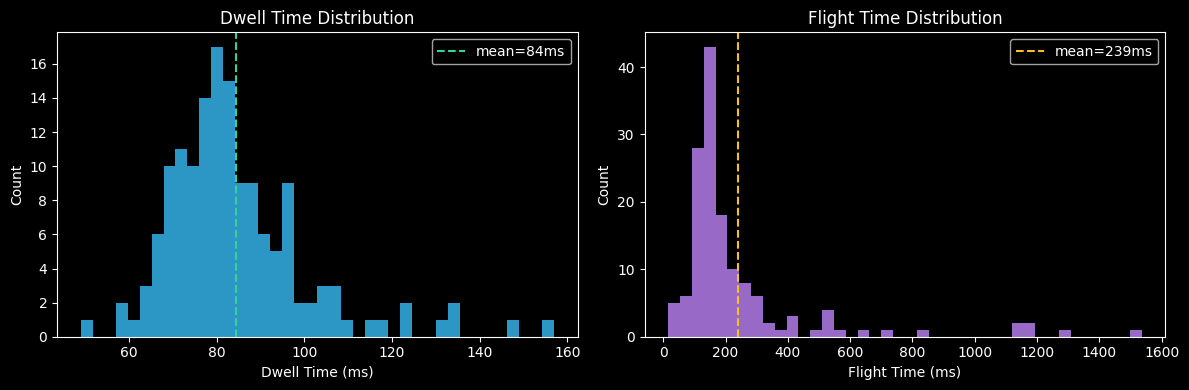

✓ Plot saved to data/processed/


In [2]:
# Cell 2 — Plot Dwell Time Distribution
import sys
sys.path.append('../src')
from features import compute_dwell, compute_flight
import matplotlib.pyplot as plt
import matplotlib.style
matplotlib.style.use('dark_background')

dwell_df  = compute_dwell(df)
flight_df = compute_flight(df)

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Dwell time histogram
axes[0].hist(dwell_df['dwell_ms'], bins=40,
            color='#38bdf8', alpha=0.8, edgecolor='none')
axes[0].set_title('Dwell Time Distribution', color='white')
axes[0].set_xlabel('Dwell Time (ms)')
axes[0].set_ylabel('Count')
axes[0].axvline(dwell_df['dwell_ms'].mean(),
                color='#34d399', linestyle='--',
                label=f'mean={dwell_df["dwell_ms"].mean():.0f}ms')
axes[0].legend()

# Flight time histogram
axes[1].hist(flight_df['flight_ms'], bins=40,
            color='#c084fc', alpha=0.8, edgecolor='none')
axes[1].set_title('Flight Time Distribution', color='white')
axes[1].set_xlabel('Flight Time (ms)')
axes[1].set_ylabel('Count')
axes[1].axvline(flight_df['flight_ms'].mean(),
                color='#fbbf24', linestyle='--',
                label=f'mean={flight_df["flight_ms"].mean():.0f}ms')
axes[1].legend()

plt.tight_layout()
plt.savefig('../data/processed/dwell_flight_plot.png', dpi=120)
plt.show()
print("✓ Plot saved to data/processed/")